# W01 Mon — Setup and Orientation
## IIT414W · Unit I · Week 1 · Mon March 2, 2026

**Learning goals for this session:**
- Verify Python, conda/pip, Jupyter, and Git are correctly installed.
- Clone the course repo and run a reproducibility check.
- Understand the vibe-coder vs. agentic-engineer spectrum.
- Make a F1 winner prediction (intuition-based, no model) and document it.

**Before you start:** Confirm your environment is created from `environment.yml` or `requirements.txt` and that Git is available in your terminal.



In [1]:
# ── Reproducibility Header ────────────────────────────────────────────
# Every notebook in IIT414W starts here. Do not skip this block.

import sys, random
import numpy as np
import warnings

RANDOM_SEED = 414  # Course constant. Do not change.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore', category=FutureWarning)

# Environment check
print(f'Python  : {sys.version.split()[0]}')
print(f'NumPy   : {np.__version__}')
print(f'Seed    : {RANDOM_SEED}')


Python  : 3.13.7
NumPy   : 2.4.2
Seed    : 414


In [2]:
# ── Dependency Guard ───────────────────────────────────────────────
# Ensures all required packages are installed in the active kernel.
# Safe to re-run: pip will skip already-installed packages.

import importlib, subprocess, sys

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'fastf1': 'fastf1',
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Installing missing packages: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Done. Packages installed successfully.')
else:
    print('All required packages already installed ✓')

# ── Library Imports ───────────────────────────────────────────────
import os                        # Working directory checks
import subprocess                # Git command checks
import importlib                 # Runtime dependency checks
import numpy as np               # Numeric support
import pandas as pd              # Tables and diagnostics
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Statistical plotting
import fastf1                    # Formula 1 data access

print(f'fastf1  : {fastf1.__version__}')
print(f'pandas  : {pd.__version__}')

All required packages already installed ✓
fastf1  : 3.8.1
pandas  : 2.3.3


## 1. Environment Verification

**The idea.** We verify that the full local toolchain works before any analysis.

**In F1 terms.** A team validates telemetry feeds before strategy simulation.

> **Why it matters:** Setup problems masquerade as modeling mistakes if not checked first.


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > How will we prove this machine can reproduce course notebooks from scratch?

2. **What does success look like? How will we know if the result is good?**
   > It will be good if the code and outpouts works correctly and most important it can be reproduced in any computer installing the requirements

3. **What could go wrong? Name one failure mode.**
   > Can go wrong if a library is missing in the requirements or isn't installed correctly, also if for some reason the computer or memory it's lower


In [3]:
required = ['numpy', 'pandas', 'sklearn', 'matplotlib', 'seaborn', 'fastf1']
rows = []
for pkg in required:
    mod = importlib.import_module(pkg)
    rows.append((pkg, getattr(mod, '__version__', 'n/a')))

print(pd.DataFrame(rows, columns=['package', 'version']).to_string(index=False))
print(f'Working directory: {os.getcwd()}')

# FastF1 cache — auto-create if missing
cache_path = os.path.join(os.path.dirname(os.getcwd()), '..', 'data', 'fastf1_cache')
cache_path = os.path.abspath(cache_path)
os.makedirs(cache_path, exist_ok=True)
fastf1.Cache.enable_cache(cache_path)
print(f'FastF1 cache enabled: {cache_path}')

print(subprocess.run(['git', '--version'], capture_output=True, text=True, check=False).stdout.strip())
log = subprocess.run(['git', 'log', '--oneline', '-5'], capture_output=True, text=True, check=False)
print('Recent commits:')
print(log.stdout.strip() if log.returncode == 0 else 'No commit history available in this folder.')

   package version
     numpy   2.4.2
    pandas   2.3.3
   sklearn   1.8.0
matplotlib  3.10.8
   seaborn  0.13.2
    fastf1   3.8.1
Working directory: e:\Udd\Semestre_4\Artificial_Intelligence\IIT414W\iit414w-lab00-marguerr04
FastF1 cache enabled: e:\Udd\Semestre_4\Artificial_Intelligence\data\fastf1_cache
git version 2.45.1.windows.1
Recent commits:
56ff9f2  final update lab 0
8c5ba88 final Lab 0 test
4e41407 comprobacion de entorno virtual reproducible
cf2e3c8 Save progress and preparation to deliver
e45315e Estructura inicial Lab 0


In [4]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Run one additional system check and explain why it supports reproducibility.
# Expected output: A short printout plus one risk note.
# Hint: You can check `sys.executable`, platform info, or free disk space.


import shutil
# One additional system check it's the free disk space. it can be obvious in small projects, but in large projects with big 
# dataset or with complex model isn't obvious, it's necesary to know how much memory disk we need to use, and if
# our computes will be capable of reproduce the experiment, we can use GB to summarize this by the formula 1Gb = 10^-9 Bytes

current_dir = os.getcwd()
total_mem = (shutil.disk_usage(current_dir).total / (10**9) )
free_mem = ( shutil.disk_usage(current_dir).free / (10**9) )
print(f'The current directory its : {current_dir}')
print(f'The total memory its : {total_mem:.2f} GB')
print(f'The free memory available its : {free_mem:.2f} GB')
print("(important) Knowing the free disk space is crucial for reproducibility in large datasets and complex projects.")


The current directory its : e:\Udd\Semestre_4\Artificial_Intelligence\IIT414W\iit414w-lab00-marguerr04
The total memory its : 250.06 GB
The free memory available its : 27.73 GB
(important) Knowing the free disk space is crucial for reproducibility in large datasets and complex projects.


In [5]:
# ── REFERENCE IMPLEMENTATION ──────────────────────────────────────
# This cell is intentionally left sparse in the student version.
# See solutions/ branch for full implementation.


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**

I learn to prevent and diagnostic the actual state of the "working place" before doing anything
I also improve mi sistem of think and documentation in the code


2. **Where could this technique fail or mislead you?**
It requires time and analysis to prove that everything will work correctly
sacrifices production with high quality of project




3. **How would you explain this to a non-technical teammate?**
Before start a "building" you need to ensure hoy have all the tools 
the weather and construction zone is fine, in informatic it's the same

## 2. The Vibe Coder vs. Agentic Engineer

**The idea.** Agentic workflows require explicit decisions, checks, and evidence.

**In F1 terms.** Race engineers never trust a single number without validating context and assumptions.

> **Why it matters:** Decision quality, not code volume, is what we grade in this course.


### Spectrum Examples — Code Snippets

**Example 1 — AI suggests a train/test split:**

Vibe Coder:
```python
# AI says: just use train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# "Looks fine!" → ships it
```

Agentic Engineer:
```python
# Wait — is this temporal data? Random split could leak future info.
# Check: are there date columns? Is order meaningful?
print(df['year'].unique())  # 2019, 2020, 2021, 2022, 2023
# → Random split mixes years. Must split by time, not randomly.
```

**Example 2 — Model accuracy is 92%:**

Vibe Coder:
```python
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")  # 0.92
# "Great score!" → done
```

Agentic Engineer:
```python
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")  # 0.92
print(f"Majority baseline: {y_test.mean():.2f}")          # 0.90
# → Only 2% above always-predicting-majority. Basically useless.
```

**Example 3 — AI generates a feature engineering function:**

Vibe Coder:
```python
# Copies AI output directly into pipeline → no validation
def engineer_features(df):
    df['avg_position'] = df.groupby('driver')['position'].transform('mean')
    return df  # Uses future races to compute mean → leakage!
```

Agentic Engineer:
```python
# Before using: Does this use future information?
# 'mean' over ALL rows includes future races → target leakage!
# Fix: use expanding mean up to current race only
df['avg_position'] = df.groupby('driver')['position'].transform(
    lambda x: x.shift(1).expanding().mean()
)
```

| Scenario | Vibe Coder | Agentic Engineer |
|---|---|---|
| AI suggests code | Copies and runs | Tests assumptions and edge cases |
| Plot looks clean | Accepts narrative | Verifies labels, units, and sampling |
| Metric improves | Declares success | Checks leakage and baseline comparisons |

### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > Which one of your current coding habits is most likely to create silent errors?

2. **What does success look like? How will we know if the result is good?**
   > It's success when we anticipate possible future errors and have clarity of the working space in detail and documented

3. **What could go wrong? Name one failure mode.**
   > Even with some preparation still can be error or don't have a clear plan
   of hot to manage some problems


In [6]:
self_check = pd.DataFrame(
    {
        'statement': [
            'I define success metrics before coding',
            'I verify train/val/test leakage explicitly',
            'I validate AI-generated code before reuse',
            'I document failed attempts',
            'I justify every modeling decision in writing',
        ],
        'score_1_to_5': [None, None, None, None, None],
    }
)
print(self_check.to_string(index=False))


                                   statement score_1_to_5
      I define success metrics before coding         None
  I verify train/val/test leakage explicitly         None
   I validate AI-generated code before reuse         None
                  I document failed attempts         None
I justify every modeling decision in writing         None


In [7]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Fill the checklist and write one concrete action to improve your lowest-scoring item.
# Expected output: A completed table and one action sentence.
# Hint: Honest scoring is more useful than optimistic scoring.

self_check = pd.DataFrame(
    {
        'statement': [
            'I define success metrics before coding',
            'I verify train/val/test leakage explicitly',
            'I validate AI-generated code before reuse',
            'I document failed attempts',
            'I justify every modeling decision in writing',
        ],
        'score_1_to_5': [1, 2, 2, 1, 4],
    }
)
print(self_check.to_string(index=False))

print('\nOne action to improve its to document the system of process and descicion, justifying rationale the documentation and his implementation')


                                   statement  score_1_to_5
      I define success metrics before coding             1
  I verify train/val/test leakage explicitly             2
   I validate AI-generated code before reuse             2
                  I document failed attempts             1
I justify every modeling decision in writing             4

One action to improve its to document the system of process and descicion, justifying rationale the documentation and his implementation


In [8]:
# ── REFERENCE IMPLEMENTATION ──────────────────────────────────────
# This cell is intentionally left sparse in the student version.
# See solutions/ branch for full implementation.


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**

We expect to have a clear idea of what we are doing and what we expect of the use of AI
It's use to improve our results, with clear metrics to have regulation about the use, to avoid 
missunderstoods and have a documentation about his use in future projects

2. **Where could this technique fail or mislead you?**

May fail if someone don't have a clear idea of what they are doing, with a confident of the AI
until some errors appears

3. **How would you explain this to a non-technical teammate?**

The use of AI is expected, not for replacing or do all the job, it's a 
tool to make easier and faster some documentation, test, and explanation to
have a professional work in time.



## 3. Your First F1 Data Pull

**The idea.** We pull real FastF1 data and inspect lap-level structure before modeling.

**In F1 terms.** This is like opening timing screens before deciding race strategy.

> **Why it matters:** Early data literacy prevents poor feature assumptions later.


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > What pattern do you expect to see in top-driver qualifying lap distributions?
I expect an normal distribution in the middle and a extreme difference in the first places
2. **What does success look like? How will we know if the result is good?**
   > Sucess will be sucess if the normal test or distribution test has an accuracy/correlation about 0.9 or more

3. **What could go wrong? Name one failure mode.**
   > The distribution isn't regular as expected, the skip of the outliers


core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '55', '27', '1', '10', '63', '14', '77', '11', '22', '30', '18', '16', '20', '23', '24', '44', '43', '61']


First 5 laps for VER:
Driver  LapNumber                LapTime Compound
   VER        2.0 0 days 00:01:23.516000     SOFT
   VER        3.0 0 days 00:01:56.133000     SOFT
   VER        5.0 0 days 00:01:23.612000     SOFT
   VER        6.0 0 days 00:01:35.987000     SOFT
   VER        8.0 0 days 00:01:22.998000     SOFT


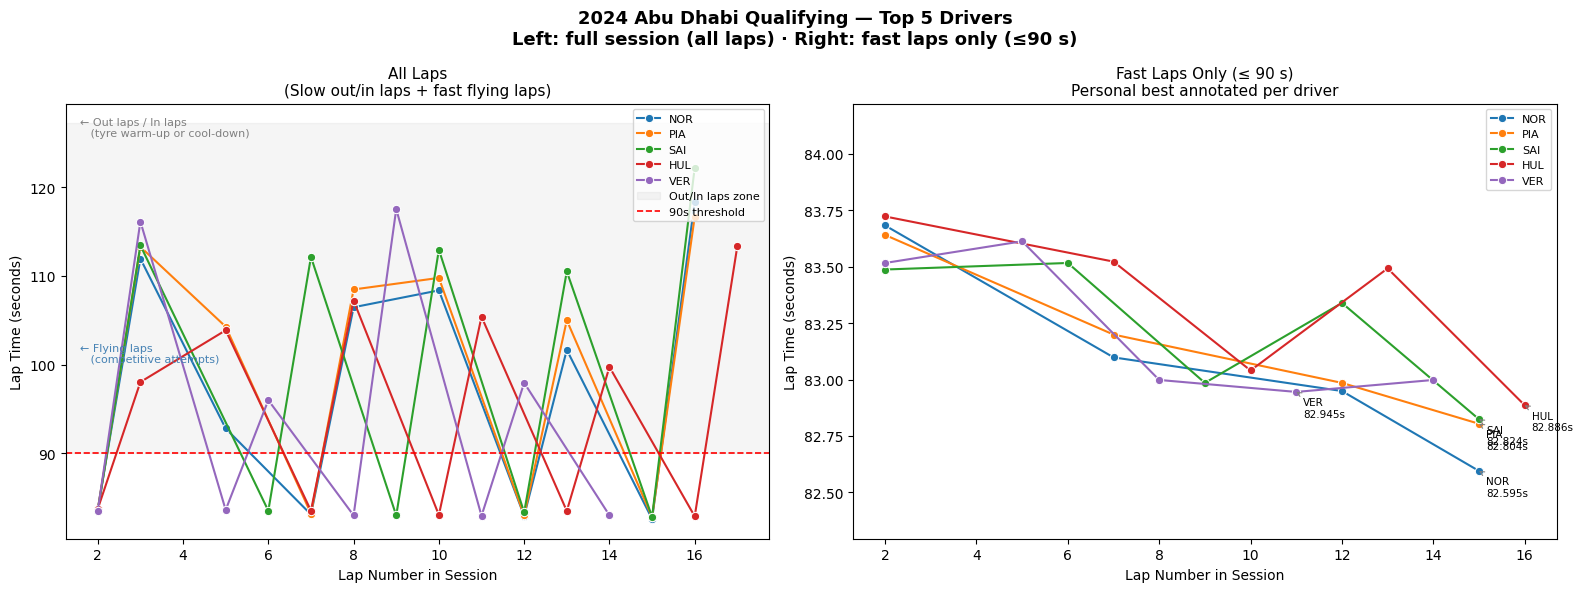


── Best Qualifying Lap per Driver (Top 5) ──
Driver  BestLapSec  GapToPole
   NOR      82.595      0.000
   PIA      82.804      0.209
   SAI      82.824      0.229
   HUL      82.886      0.291
   VER      82.945      0.350

💡 GapToPole: how many seconds behind the fastest qualifier each driver was.


In [9]:
# ── Load a Formula 1 Session ──────────────────────────────────────────────────
# fastf1.get_session() identifies a session by: year, event name (or round number), and session type.
# Session types: 'FP1', 'FP2', 'FP3' (Free Practice), 'Q' (Qualifying), 'R' (Race), 'S' (Sprint)
# 'Abu Dhabi' is the final race of the 2024 F1 season (Round 24).
session = fastf1.get_session(2024, 'Abu Dhabi', 'Q')

# session.load() fetches data from the FastF1 cache (or downloads it if not cached).
# We only need lap data here, so we disable the heavier telemetry/weather/messages
# to speed up loading. Set any of these to True if you need that data later.
#   laps=True      → lap-by-lap timing data (required for this analysis)
#   telemetry=False → car sensor data (speed, throttle, brake, gear) — not needed here
#   weather=False   → track temperature, wind, rain data — not needed here
#   messages=False  → race control messages (flags, penalties) — not needed here
session.load(laps=True, telemetry=False, weather=False, messages=False)

# ── Inspect VER (Max Verstappen) Lap Data ─────────────────────────────────────
# session.laps returns a special FastF1 DataFrame (Laps object) with all drivers.
# pick_drivers('VER') filters by driver abbreviation (3-letter code used in F1 broadcasts).
# Common abbreviations: NOR=Norris, VER=Verstappen, HAM=Hamilton, LEC=Leclerc, etc.
# LapTime is stored as a pandas Timedelta (days + HH:MM:SS.microseconds), not a float.
# dropna() removes laps where any selected column has missing data (e.g. aborted laps).
ver_laps = session.laps.pick_drivers('VER')[['Driver', 'LapNumber', 'LapTime', 'Compound']].dropna().head(5)
print('First 5 laps for VER:')
print(ver_laps.to_string(index=False))

# ── Get the Top 5 Qualifiers from Official Results ────────────────────────────
# session.results is a DataFrame with one row per driver, containing official timing.
# In qualifying, Position=1 is pole position (fastest overall Q3 time).
# We copy it to avoid accidentally modifying the original session data.
res = session.results.copy()

# Position can sometimes be stored as a string or mixed type — coerce to numeric.
# errors='coerce' turns any non-numeric value into NaN instead of raising an error.
res['Position'] = pd.to_numeric(res['Position'], errors='coerce')

# nsmallest(5, 'Position') picks the 5 rows with the lowest (best) position numbers.
# 'Abbreviation' gives us the 3-letter driver codes we need for lap filtering.
top5 = res.nsmallest(5, 'Position')['Abbreviation'].tolist()

# ── Build Plotting DataFrame for Top 5 Drivers ───────────────────────────────
# pick_drivers() also accepts a list of abbreviations — it returns all laps for those drivers.
# We keep only the columns we need for plotting: driver name, lap number, and lap time.
# .copy() ensures we work on a fresh DataFrame and not a view (avoids SettingWithCopyWarning).
plot_df = session.laps.pick_drivers(top5)[['Driver', 'LapNumber', 'LapTime']].dropna().copy()

# Convert Timedelta → float (seconds) for easy plotting on a numeric Y axis.
# dt.total_seconds() works on Timedelta columns; e.g. 0 days 00:01:22.595 → 82.595
plot_df['LapTimeSec'] = plot_df['LapTime'].dt.total_seconds()

# ── Separate fast laps from slow laps for cleaner visualization ───────────────
# In qualifying, drivers do:
#   - OUT LAPS  : slow laps to warm up tyres before a fast attempt  (> ~90s here)
#   - FLYING LAPS: the actual timed competitive laps               (<= ~90s here)
#   - IN LAPS   : slow laps returning to the pit box               (> ~90s here)
# We use 90 seconds as a threshold — anything faster is likely a competitive lap.
# Abu Dhabi circuit lap record is ~82s, so 90s gives us a comfortable margin.
# NOTE: This threshold is circuit-specific. For Monaco (~74s lap record) you'd use ~85s;
#       for Monza (~80s) you might use ~88s. Always check before applying.
FAST_LAP_THRESHOLD = 90  # seconds — adjust if session is at a shorter/longer circuit

fast_laps = plot_df[plot_df['LapTimeSec'] <= FAST_LAP_THRESHOLD]
slow_laps = plot_df[plot_df['LapTimeSec'] > FAST_LAP_THRESHOLD]

# ── Plot: Two panels side by side ─────────────────────────────────────────────
# plt.subplots(1, 2) creates a figure with 1 row and 2 columns of Axes (subplots).
# figsize=(16, 6) sets the figure width=16 inches, height=6 inches.
# axes[0] = left panel, axes[1] = right panel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    '2024 Abu Dhabi Qualifying — Top 5 Drivers\n'
    'Left: full session (all laps) · Right: fast laps only (≤90 s)',
    fontsize=13, fontweight='bold'
)

# ── LEFT PANEL: All laps — shows the full qualifying rhythm ───────────────────
# This panel helps students understand the structure of a qualifying session:
# Q1 (all 20 cars) → Q2 (top 15) → Q3 (top 10), each separated by slow in/out laps.
ax = axes[0]

# sns.lineplot with hue='Driver' automatically assigns a different color per driver
# and draws a line connecting their laps in order. marker='o' adds a dot at each lap.
sns.lineplot(data=plot_df, x='LapNumber', y='LapTimeSec',
             hue='Driver', marker='o', ax=ax)

# axhspan shades a horizontal band between two Y values across the full X range.
# This visually marks the "slow lap" region (out laps and in laps).
# alpha=0.08 makes the shading very transparent so lines remain readable.
ax.axhspan(FAST_LAP_THRESHOLD, plot_df['LapTimeSec'].max() + 5,
           alpha=0.08, color='gray', label='Out/In laps zone')

# axhline draws a horizontal reference line at y=FAST_LAP_THRESHOLD.
# linestyle='--' = dashed line; this is the boundary between slow and fast laps.
ax.axhline(FAST_LAP_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
           label=f'{FAST_LAP_THRESHOLD}s threshold')

ax.set_title('All Laps\n(Slow out/in laps + fast flying laps)', fontsize=11)
ax.set_xlabel('Lap Number in Session')
ax.set_ylabel('Lap Time (seconds)')
ax.legend(fontsize=8, loc='upper right')

# ax.text with transform=ax.transAxes uses Axes-relative coordinates:
# (0, 0) = bottom-left corner, (1, 1) = top-right corner of the plot area.
# This keeps the annotation in the same relative position regardless of data range.
ax.text(0.02, 0.97, '← Out laps / In laps\n   (tyre warm-up or cool-down)',
        transform=ax.transAxes, fontsize=8, va='top', color='gray')
ax.text(0.02, 0.45, '← Flying laps\n   (competitive attempts)',
        transform=ax.transAxes, fontsize=8, va='top', color='steelblue')

# ── RIGHT PANEL: Fast laps only — reveals true pace comparison ────────────────
# Removing the out/in laps compresses the Y axis, making small differences
# between drivers (often < 0.5s in qualifying) clearly visible.
ax = axes[1]
sns.lineplot(data=fast_laps, x='LapNumber', y='LapTimeSec',
             hue='Driver', marker='o', ax=ax)

# Annotate the personal best lap for each driver.
# idxmin() returns the index label of the minimum value in the Series.
# ax.annotate() places a text label with an arrow pointing to the data point.
for driver in top5:
    driver_fast = fast_laps[fast_laps['Driver'] == driver]
    if driver_fast.empty:
        continue
    best_row = driver_fast.loc[driver_fast['LapTimeSec'].idxmin()]
    ax.annotate(
        f"{driver}\n{best_row['LapTimeSec']:.3f}s",  # .3f = 3 decimal places (millisecond precision)
        xy=(best_row['LapNumber'], best_row['LapTimeSec']),  # arrow tip: the actual data point
        xytext=(5, -18), textcoords='offset points',         # label offset in pixels from the tip
        fontsize=7.5, color='black',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
    )

ax.set_title('Fast Laps Only (≤ 90 s)\nPersonal best annotated per driver', fontsize=11)
ax.set_xlabel('Lap Number in Session')
ax.set_ylabel('Lap Time (seconds)')
ax.legend(fontsize=8, loc='upper right')

# Tighten y-axis so small differences between drivers are visible.
# Without this, matplotlib auto-scales to include 0 on the Y axis,
# making a 0.3s gap between pole and P5 almost invisible.
y_min = fast_laps['LapTimeSec'].min()
y_max = fast_laps['LapTimeSec'].max()
ax.set_ylim(y_min - 0.3, y_max + 0.5)  # small padding around the actual data range

# tight_layout() automatically adjusts subplot spacing to prevent label overlap.
plt.tight_layout()
plt.show()

# ── Summary table: Best lap per driver ────────────────────────────────────────
# This table makes it easy to compare pole-lap pace without reading from the chart.
print('\n── Best Qualifying Lap per Driver (Top 5) ──')
best_laps = (
    fast_laps.groupby('Driver')['LapTimeSec']
    .min()                                          # best (minimum) lap time per driver
    .reset_index()                                  # turn the groupby result back into a flat DataFrame
    .rename(columns={'LapTimeSec': 'BestLapSec'})
    .sort_values('BestLapSec')                      # sort fastest → slowest (pole position first)
)
# GapToPole: difference between each driver's best lap and the pole-sitter's best lap.
# iloc[0] is the pole-sitter after sort_values, so subtracting gives 0.000 for pole.
best_laps['GapToPole'] = (best_laps['BestLapSec'] - best_laps['BestLapSec'].iloc[0]).round(3)
print(best_laps.to_string(index=False))
print('\n💡 GapToPole: how many seconds behind the fastest qualifier each driver was.')


In [10]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Compare one additional driver against VER and summarize variance differences.
# Expected output: A table and one interpretation sentence.
# Hint: Use standard deviation of lap times in seconds.


# The conductor will be Hul
df_hul = fast_laps[fast_laps['Driver'].isin(['VER', 'HUL'])]
df_hul


,Driver,LapNumber,LapTime,LapTimeSec
49,HUL,2.0,0 days 00:01:23.722000,83.722
54,HUL,7.0,0 days 00:01:23.522000,83.522
57,HUL,10.0,0 days 00:01:23.040000,83.040
60,HUL,13.0,0 days 00:01:23.492000,83.492
63,HUL,16.0,0 days 00:01:22.886000,82.886
66,VER,2.0,0 days 00:01:23.516000,83.516
69,VER,5.0,0 days 00:01:23.612000,83.612
72,VER,8.0,0 days 00:01:22.998000,82.998
75,VER,11.0,0 days 00:01:22.945000,82.945
78,VER,14.0,0 days 00:01:22.998000,82.998


In [11]:
# There aren't outliers , we can compare 


df_result = df_hul.groupby('Driver')['LapTimeSec'].var().reset_index()
df_result = df_result.rename(columns = {'LapTimeSec' : 'Variance'})
display(df_result)
var_dif = abs(df_result.loc[0, 'Variance'] - df_result.loc[1, 'Variance'])
print(f'the variance difference its : {var_dif:.4f}')

print('While Verstappen has a faster absolute pace, both drivers show a very low standard deviation with a difference of 0.0207 ')

,Driver,Variance
0,HUL,0.124495
1,VER,0.103820


the variance difference its : 0.0207
While Verstappen has a faster absolute pace, both drivers show a very low standard deviation with a difference of 0.0207 


To compare bettrer nest will be a plot to make a visualization between the Driver Hul and driver Ver


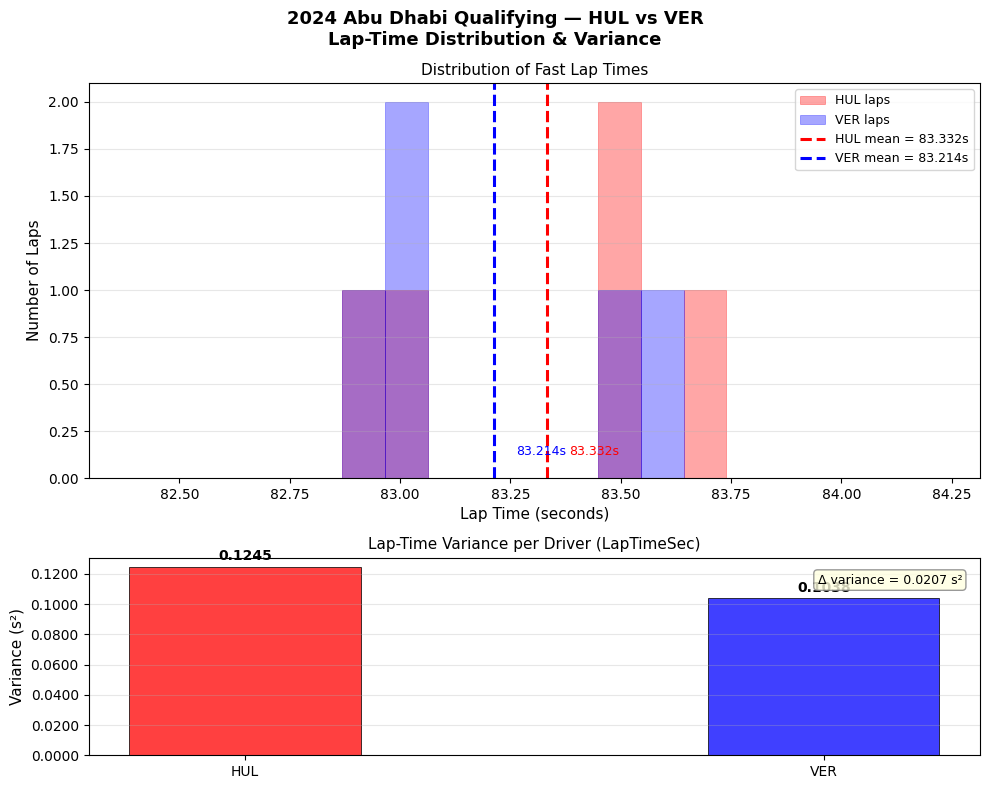

HUL mean lap time : 83.332s  |  variance : 0.1245 s²
VER mean lap time : 83.214s  |  variance : 0.1038 s²
Δ mean            : 0.119s  |  Δ variance : 0.0207 s²


In [12]:

# ── HUL vs VER: Lap-Time Distribution + Variance Subplot ──────────────────────
# df_hul already contains fast laps for HUL and VER (built in the cell above).
# We use a KDE / histogram to show how each driver's lap-time spread looks,
# then a bar subplot below to compare their variances directly.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Separate by driver ────────────────────────────────────────────────────────
hul_times = df_hul[df_hul['Driver'] == 'HUL']['LapTimeSec']
ver_times = df_hul[df_hul['Driver'] == 'VER']['LapTimeSec']

hul_mean = hul_times.mean()
ver_mean = ver_times.mean()
hul_var  = hul_times.var()
ver_var  = ver_times.var()

# ── Layout: 2 rows, 1 column ──────────────────────────────────────────────────
# Top (ax_dist) : distribution of lap times with mean lines
# Bottom (ax_var): bar chart comparing variances
fig, (ax_dist, ax_var) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    gridspec_kw={'height_ratios': [3, 1.5]}
)
fig.suptitle(
    '2024 Abu Dhabi Qualifying — HUL vs VER\nLap-Time Distribution & Variance',
    fontsize=13, fontweight='bold'
)

# ── TOP PANEL: KDE + histogram ────────────────────────────────────────────────
# alpha=0.35 keeps both histograms readable when they overlap.
bins = np.linspace(
    df_hul['LapTimeSec'].min() - 0.5,
    df_hul['LapTimeSec'].max() + 0.5,
    20
)

ax_dist.hist(hul_times, bins=bins, color='red',  alpha=0.35, label='HUL laps', edgecolor='red',  linewidth=0.6)
ax_dist.hist(ver_times, bins=bins, color='blue', alpha=0.35, label='VER laps', edgecolor='blue', linewidth=0.6)

# Vertical mean lines
ax_dist.axvline(hul_mean, color='red',  linewidth=2.2, linestyle='--',
                label=f'HUL mean = {hul_mean:.3f}s')
ax_dist.axvline(ver_mean, color='blue', linewidth=2.2, linestyle='--',
                label=f'VER mean = {ver_mean:.3f}s')

# Annotate mean values at the top of each line
ax_dist.text(hul_mean + 0.05, ax_dist.get_ylim()[1] * 0.05,
             f'{hul_mean:.3f}s', color='red',  fontsize=9, va='bottom')
ax_dist.text(ver_mean + 0.05, ax_dist.get_ylim()[1] * 0.05,
             f'{ver_mean:.3f}s', color='blue', fontsize=9, va='bottom')

ax_dist.set_xlabel('Lap Time (seconds)', fontsize=11)
ax_dist.set_ylabel('Number of Laps', fontsize=11)
ax_dist.set_title('Distribution of Fast Lap Times', fontsize=11)
ax_dist.legend(fontsize=9)
ax_dist.grid(axis='y', alpha=0.3)

# ── BOTTOM PANEL: Variance comparison ────────────────────────────────────────
# A simple bar chart makes the numerical difference in variance immediately clear.
drivers  = ['HUL', 'VER']
variances = [hul_var, ver_var]
colors   = ['red', 'blue']

bars = ax_var.bar(drivers, variances, color=colors, alpha=0.75, edgecolor='black', linewidth=0.7, width=0.4)

# Label each bar with its exact variance value
for bar, val in zip(bars, variances):
    ax_var.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(variances) * 0.02,
        f'{val:.4f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax_var.set_ylabel('Variance (s²)', fontsize=11)
ax_var.set_title('Lap-Time Variance per Driver (LapTimeSec)', fontsize=11)
ax_var.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
ax_var.grid(axis='y', alpha=0.3)

# Annotate the variance difference
var_diff = abs(hul_var - ver_var)
ax_var.text(
    0.98, 0.92,
    f'Δ variance = {var_diff:.4f} s²',
    transform=ax_var.transAxes,
    ha='right', va='top', fontsize=9,
    color='black',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8)
)

plt.tight_layout()
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────────
print(f"HUL mean lap time : {hul_mean:.3f}s  |  variance : {hul_var:.4f} s²")
print(f"VER mean lap time : {ver_mean:.3f}s  |  variance : {ver_var:.4f} s²")
print(f"Δ mean            : {abs(hul_mean - ver_mean):.3f}s  |  Δ variance : {var_diff:.4f} s²")


In [13]:
# ── REFERENCE IMPLEMENTATION ──────────────────────────────────────
# This cell is intentionally left sparse in the student version.
# See solutions/ branch for full implementation.


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**

I learn to be clear in document the process

2. **Where could this technique fail or mislead you?**

Not exploring or comparing with more rada

3. **How would you explain this to a non-technical teammate?**

I would explain that even if it's simple it's necesary to review and analize data and the metodology

## 4. Prediction Card Activity

**The idea.** We capture a structured forecast before formal modeling begins.

**In F1 terms.** Teams commit assumptions before race outcomes are known, then revisit them.

> **Why it matters:** Documented assumptions reduce hindsight bias and improve learning loops.


### Prediction Card (fill this markdown cell)

1. **Who will win the 2025 Drivers' Championship?**

Redbull 

2. **What data would you use to support that prediction?**

The data of 2024 fasftf1 for example

3. **What could go wrong with your prediction?**

Something in the enviroment or the day of the career or randomness could affect in the final result


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > What assumptions are you making about the 2025 championship winner right now?

2. **What does success look like? How will we know if the result is good?**
   > See a pattern in the winner, like initial position, car spent, etc

3. **What could go wrong? Name one failure mode.**
   > The winner may be winner by a random variable, luck, or doesn't have a predictible pattern


In [14]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Fill the prediction card in this notebook and keep it for Week 6 revisit.
# Expected output: A completed dictionary with explicit assumptions.
# Hint: Be specific about what could invalidate your prediction.

prediction_card_template = {
    'predicted_2025_champion': 'Redbull',
    'evidence_plan': ['Dataset of 2024 race', 'Comparison of the average finish position of the last 5-10 races', '[feature/data source 3]'],
    'failure_modes': ['Not considering other data', 'Overfitting the model with a lot of unnecesary data'],
}
print(prediction_card_template)


{'predicted_2025_champion': 'Redbull', 'evidence_plan': ['Dataset of 2024 race', 'Comparison of the average finish position of the last 5-10 races', '[feature/data source 3]'], 'failure_modes': ['Not considering other data', 'Overfitting the model with a lot of unnecesary data']}


In [15]:
# ── REFERENCE IMPLEMENTATION ──────────────────────────────────────
# This cell is intentionally left sparse in the student version.
# See solutions/ branch for full implementation.


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**

Nothing in particular, but it's interesting to be methodical and practical, exploring the data and asking questions


2. **Where could this technique fail or mislead you?**

Maybe if the analysis of data doesn't has value and spending a lot of time in this process

3. **How would you explain this to a non-technical teammate?**

Spending time in exploring data it's not a waste of time, it's necesary to comprehend and make hypothesis, it can make a clear progress in future 
in analysis


## 5. What Is Machine Learning? (Conceptual Anchor)

**The idea.** ML can be explained at intuitive, technical, and formal levels.

**In F1 terms.** A model is like a pit strategy simulator: useful under known conditions, fragile under shifts.

> **Why it matters:** Clear conceptual framing prevents wrong targets and wrong metrics.


### ML Taxonomy in F1

- **Supervised:** Predict Top-10 finish from pre-race features.
- **Unsupervised:** Cluster circuits by pace profile.
- **Reinforcement Learning:** Optimize pit timing via simulated reward.


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > Which ML paradigm best matches each F1 task: winner prediction, circuit clustering, pit strategy optimization?

2. **What does success look like? How will we know if the result is good?**
   > We will know it's good if we can clearly justify why winner prediction needs Supervised Learning because we want to predict an outcome, circuit clustering needs Unsupervised Learning because we are trying to find patterns, and pit strategy maybe needs Reinforcement Learning  for complex rules

3. **What could go wrong? Name one failure mode.**
   > Use an incorrect paradigm , the model will produce an incorrect or an incosistent paradigm .
   Othe thing that could be wrong it's to ingest incorrect or not cleaning data, this can produce that the model is predicting
   with wrong information, for example train or use the data we want to predict, this won't be useful 

In [16]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=500, n_features=6, n_informative=4, random_state=RANDOM_SEED)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED)

model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(f'Synthetic supervised demo accuracy: {accuracy_score(y_test, pred):.3f}')


Synthetic supervised demo accuracy: 0.960


In [17]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Create a 3-row table: supervised, unsupervised, reinforcement learning with one F1 use case each.
# Expected output: A concise paradigm-to-use-case table.
# Hint: Include one risk if each paradigm is misapplied.


import pandas as pd

paradigm_to_use_case = pd.DataFrame(
    [
        {
            "paradigm": "Supervised Learning",
            "f1_use_case": "Predict whether a driver will finish Top-10 from pre-race features",
            "risk_if_misapplied": "Using leaked time data or noisy labels can produce overconfident but wrong predictions., overfotting is a risk too",
        },
        {
            "paradigm": "Unsupervised Learning",
            "f1_use_case": "Cluster circuits by pace profile and tire degradation behavior",
            "risk_if_misapplied": "Forcing clusters without validation can create fake new groups that mislead strategy decisions.",
        },
        {
            "paradigm": "Reinforcement Learning",
            "f1_use_case": "Optimize pit-stop timing through reward-based race simulation",
            "risk_if_misapplied": "A poorly designed reward may optimize lap time while ignoring other constraints, overfitting can be a risk.",
        },
    ]
)

print(paradigm_to_use_case.to_string(index=False))



              paradigm                                                        f1_use_case                                                                                                 risk_if_misapplied
   Supervised Learning Predict whether a driver will finish Top-10 from pre-race features Using leaked time data or noisy labels can produce overconfident but wrong predictions., overfotting is a risk too
 Unsupervised Learning     Cluster circuits by pace profile and tire degradation behavior                    Forcing clusters without validation can create fake new groups that mislead strategy decisions.
Reinforcement Learning      Optimize pit-stop timing through reward-based race simulation        A poorly designed reward may optimize lap time while ignoring other constraints, overfitting can be a risk.


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**

I learning to predict the outcome of models before doing , this can make easier decide why use one model or other
tis also help in the documentation process of the project to new partners

2. **Where could this technique fail or mislead you?**

This can fail if you can't comprehend data/isn't clean or the paradigm of the use_case can be have an exception due to business needs 

3. **How would you explain this to a non-technical teammate?**

To make a model it's necessary to understand the business, this can help in the future descicions and
understand the outpouts of the models



## 🎟️ Exit Ticket

Before you close this notebook, answer these 3 questions:

1. **One thing I understood well today:**

The expectation about us is to pass from "vibe coding", were we don't understand and the errors it's for the AI - to be Agentic Engineerings having the best habits of Engineering and using the AI with knoledge and responsability for out deliverys and projects

2. **One thing I am still confused about:**

The process of make an evaluate pipelines, and how to formalize and document our projects


3. **One thing I would do differently next time:**

I would ask for terms i don't know and try to take notes from myself to be clear that I have understood


> Submit your answers in Canvas (Exit Ticket Week 1 - Monday) before leaving class.


## 🤖 AI Usage Log

If you used any AI tool (Copilot, Claude, ChatGPT, etc.) during this session, document it here.
Then copy this to your `PROMPTS.md` file.

| # | Tool | Prompt (summary) | Output (summary) | Accepted / Modified / Rejected | Why |
|---|---|---|---|---|---|
| 1 | | | | | |

**Verification steps I took to validate the AI output:**
> I checked first the outpout if it was was i expected, like a fix or a plot, next, I revieew how the AI do the work, and ask why or how make some operations, with the ansewer I decide if the output was useful or not
**What I would NOT trust the AI to do without checking:**
> I would no trust the Ai do without checking in making descicions about the dataset or Choosing columns or variables for 
Machine learning, this because the business needs can be difficult to interpretate, and also because it's the most critical 
step in building a model, it's important to review the output and justifications for this descicions.
